# B9.1 Basic Fourier Analysis
<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B9.1.1 Motivation: Why Fourier Analysis?

Before we move deeper into quantum mechanics, we need to understand the basic idea of **Fourier analysis**.

---

### Many Waves Acting Together

In classical physics, we are used to describing a wave with a single frequency or wavelength.  
But in quantum mechanics, **particles are described by wave packets**, not just single sine waves.

- A single sine wave extends infinitely → not a good description for a particle localized in space.
- A localized wave packet is built by **adding many different sine and cosine waves together**.

Fourier analysis is simply the **tool that tells us how to build complicated shapes from simple waves**.

---

### Localization and Momentum

When we talk about a particle’s position and momentum:

- Position information comes from how the different waves combine in real space.
- Momentum information is tied to the **individual wave components** (each with its own wavelength).

This idea naturally leads to the **Heisenberg Uncertainty Principle**:  
the more localized the packet, the more wave components (and momentum values) it must contain.

---

### Everywhere in Physics

Fourier analysis is not just for quantum mechanics:

- **Acoustics & music** – breaking sound into frequencies.
- **Optics** – analyzing diffraction and interference patterns.
- **Signal processing** – used in almost every modern technology.

In quantum mechanics, we will use it constantly to:

1. Describe **wave packets** and localization.  
2. Move between **position space** and **momentum space** representations.

---

### Why Learn It Now?

Before we talk about wave packets, probability, and measurement in quantum mechanics, we need to understand:

- How combining many simple waves gives us localized particles.
- Why knowing position well automatically means less certainty in momentum.

---

### ⚠️ Important
This is mostly a **conceptual introduction**. No prior knowledge of advanced math is required beyond **basic calculus and trigonometry**.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B9.1.2 What is Fourier Analysis? (Big Picture)

Fourier analysis is the idea that **any wave or signal** can be written as a sum (or superposition) of many sine and cosine waves:

$$
f(x) = a_0 + \sum_{n=1}^{\infty} \left[a_n \cos(nkx) + b_n \sin(nkx)\right]
$$

In physics, we often write this more compactly using exponentials:

$$
f(x) = \frac{1}{\sqrt{2\pi}}\int_{-\infty}^{\infty} \phi(k) e^{ikx} dk
$$

*(Don’t worry about this integral for now — think of it as just adding up many $k$ components.)*

---

### Everyday Examples

- **Music:** A musical note is a combination of many frequencies.  
- **Square waves:** Built from a fundamental frequency + harmonics.  
- **Localized bumps:** Need many different wavelengths to "shape" the packet.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B9.1.3 Superposition of Waves: Building Complexity

Let’s start simple:

1. **One sine wave**: perfectly periodic.  
2. **Two slightly different sine waves**: produce a "beating" pattern.  
3. **Many sine waves**: can create a sharply localized bump.

We’ll demonstrate this below.

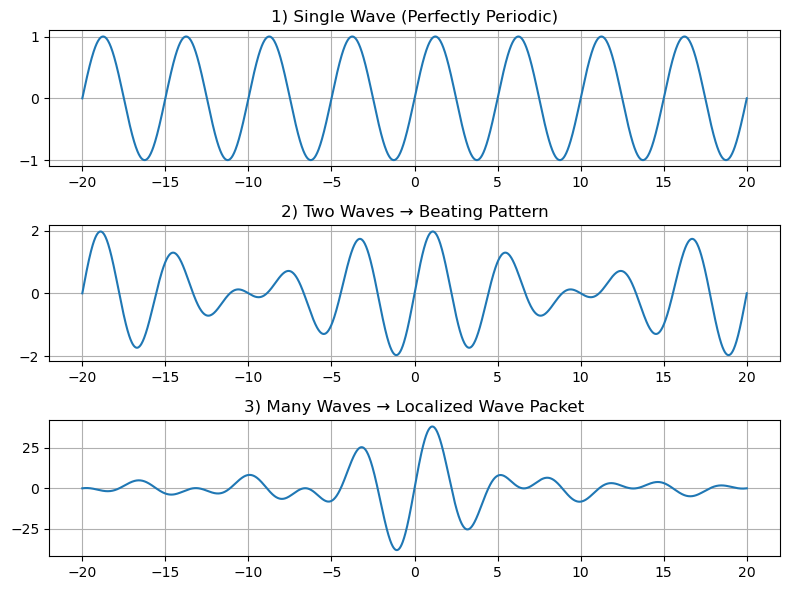

In [5]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-20, 20, 2000)

# 1) Single wave
y1 = np.sin(2*np.pi*0.2*x)

# 2) Two waves (beating)
y2 = np.sin(2*np.pi*0.2*x) + np.sin(2*np.pi*0.25*x)

# 3) Many waves (localized packet)
k_values = np.linspace(0.15,0.3,40)
y3 = sum(np.sin(2*np.pi*k*x) for k in k_values)

plt.figure(figsize=(8,6))
plt.subplot(3,1,1)
plt.plot(x,y1)
plt.title("1) Single Wave (Perfectly Periodic)")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(x,y2)
plt.title("2) Two Waves → Beating Pattern")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(x,y3)
plt.title("3) Many Waves → Localized Wave Packet")
plt.grid(True)

plt.tight_layout()
plt.show()

### Interpretation

- Adding just two frequencies produces **beats** (slowly varying envelope).
- Adding many frequencies produces a **wave packet** localized in space.

The more frequencies (or wavenumbers $k$) we include, the narrower and more localized the packet becomes.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B9.1.4 Localization vs Range of Wavenumbers

This is a general rule of Fourier analysis:

$$
\text{Narrow in } x \quad \Longleftrightarrow \quad \text{Wide in } k
$$

Mathematically (don’t memorize yet):

$$
\Delta x \, \Delta k \sim 1
$$

---

### Intuitive Analogy

- **Sharp edges need many frequencies:**  
  To make a very sharp corner in a drawing, you need to combine lots of different pencil strokes.  

- **A single frequency = smooth & infinite:**  
  A single sine wave repeats forever → no localization.

---

### Why We Care

When we describe **particles as waves**, a localized particle (small $\Delta x$) must contain many wavenumber components (large $\Delta k$).  
This will lead directly to the **Heisenberg Uncertainty Principle**.

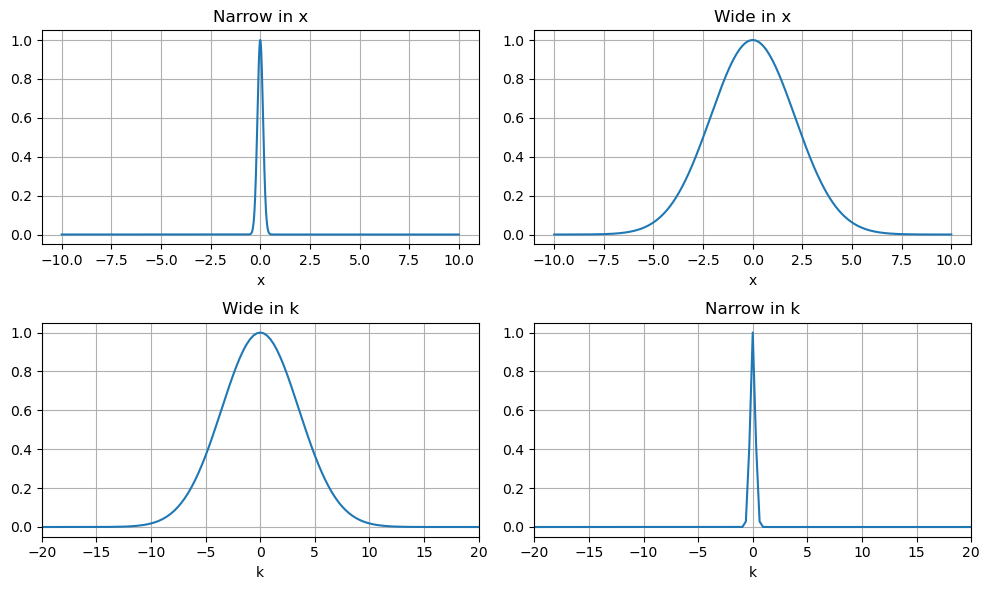

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# x-grid
N = 2048
x_max = 10
x = np.linspace(-x_max, x_max, N)
dx = x[1] - x[0]

# k-grid (shifted properly)
k = np.fft.fftshift(np.fft.fftfreq(N, d=dx)) * 2*np.pi

# Gaussian function in x-space
def gaussian_x(x, sigma):
    return (1/(np.sqrt(sigma*np.sqrt(2*np.pi)))) * np.exp(-x**2/(2*sigma**2))

# More extreme widths to emphasize trade-off
sigma_narrow = 0.2   # very narrow in x
sigma_wide = 3.0     # very wide in x

psi_narrow = gaussian_x(x, sigma_narrow)
psi_wide = gaussian_x(x, sigma_wide)

# Fourier transform (properly normalized)
phi_narrow = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(psi_narrow))) * dx / np.sqrt(2*np.pi)
phi_wide = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(psi_wide))) * dx / np.sqrt(2*np.pi)

# Probability densities (normalized to peak at 1 for clarity)
psi_narrow_prob = np.abs(psi_narrow)**2 / np.max(np.abs(psi_narrow)**2)
psi_wide_prob = np.abs(psi_wide)**2 / np.max(np.abs(psi_wide)**2)
phi_narrow_prob = np.abs(phi_narrow)**2 / np.max(np.abs(phi_narrow)**2)
phi_wide_prob = np.abs(phi_wide)**2 / np.max(np.abs(phi_wide)**2)

# Plot results
plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
plt.plot(x, psi_narrow_prob)
plt.title("Narrow in x")
plt.xlabel("x")
plt.grid(True)

plt.subplot(2,2,2)
plt.plot(x, psi_wide_prob)
plt.title("Wide in x")
plt.xlabel("x")
plt.grid(True)

plt.subplot(2,2,3)
plt.plot(k, phi_narrow_prob)
plt.title("Wide in k")
plt.xlabel("k")
plt.xlim(-20,20)  # zoom in on region of interest
plt.grid(True)

plt.subplot(2,2,4)
plt.plot(k, phi_wide_prob)
plt.title("Narrow in k")
plt.xlabel("k")
plt.xlim(-20,20)
plt.grid(True)

plt.tight_layout()
plt.show()

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## B9.1.5 Summary

- Any signal or wave can be built from many simple sine/cosine waves.  
- Adding more frequencies allows you to build localized packets.  
- Narrower localization in $x$ means a wider range of $k$ values.  
- This trade-off is fundamental to quantum physics.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">